# 02 - Solar and Battery Simulation

This notebook simulates a residential photovoltaic system with battery storage.

The goal is to understand how solar generation and battery storage affect:

- Direct solar self-consumption
- Grid electricity imports
- Solar surplus
- Battery charging and discharging
- Battery state of charge over time

This notebook uses the synthetic 30-day consumption dataset generated for the project.

In [14]:
from pathlib import Path
import sys

import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path().resolve().parent
SRC_PATH = PROJECT_ROOT / "src"

sys.path.append(str(SRC_PATH))

from data_loader import load_consumption_data
from solar import simulate_self_consumption
from solar_data_loader import (
    load_pvgis_solar_data,
    get_pvgis_generation_for_timestamps
)
from battery import simulate_battery

DATA_PATH = PROJECT_ROOT / "data" / "simulated" / "synthetic_consumption_30_days.csv"

PVGIS_PATH = PROJECT_ROOT / "data" / "raw" / "pvgis_hourly_linares_1kw_2020.csv"

## Load consumption data

We load the synthetic hourly electricity consumption dataset.

In [15]:
df = load_consumption_data(str(DATA_PATH))

df.head()

,datetime,consumption_kwh,hour,day,month,weekday
0,2025-01-01 00:00:00,0.216180,0,1,1,2
1,2025-01-01 01:00:00,0.172143,1,1,1,2
2,2025-01-01 02:00:00,0.113076,2,1,1,2
3,2025-01-01 03:00:00,0.203159,3,1,1,2
4,2025-01-01 04:00:00,0.170268,4,1,1,2


## Load PVGIS solar data

This notebook uses PVGIS hourly solar generation data for Linares, Spain.

The PVGIS file contains the estimated photovoltaic power output for a reference 1 kW system. The model scales this profile to simulate the selected PV system size.

In [16]:
pvgis_df = load_pvgis_solar_data(str(PVGIS_PATH))

pvgis_df[["datetime", "P", "solar_generation_1kw_kwh"]].head(24)

,datetime,P,solar_generation_1kw_kwh
0,2020-01-01 00:10:00,0.00,0.00000
1,2020-01-01 01:10:00,0.00,0.00000
2,2020-01-01 02:10:00,0.00,0.00000
3,2020-01-01 03:10:00,0.00,0.00000
4,2020-01-01 04:10:00,0.00,0.00000
5,2020-01-01 05:10:00,0.00,0.00000
6,2020-01-01 06:10:00,0.00,0.00000
7,2020-01-01 07:10:00,0.00,0.00000
8,2020-01-01 08:10:00,174.15,0.17415
9,2020-01-01 09:10:00,433.34,0.43334


## Simulation parameters

We define a photovoltaic system and a battery storage configuration.

In [17]:
consumption_kwh = df["consumption_kwh"].tolist()
timestamps = df["datetime"]

solar_peak_power_kw = 1.5
battery_capacity_kwh = 5.0

battery_efficiency = 0.90
max_charge_power_kw = 1.0
max_discharge_power_kw = 1.0
initial_battery_state_kwh = 0.0

## Generate solar production profile

We match the PVGIS hourly solar generation profile to the consumption timestamps and scale it according to the selected PV peak power.

In [18]:
solar_generation_kwh = get_pvgis_generation_for_timestamps(
    pvgis_df,
    timestamps,
    solar_peak_power_kw
)

df["solar_generation_kwh"] = solar_generation_kwh

df[["datetime", "consumption_kwh", "solar_generation_kwh"]].head(24)

,datetime,consumption_kwh,solar_generation_kwh
0,2025-01-01 00:00:00,0.216180,0.000000
1,2025-01-01 01:00:00,0.172143,0.000000
2,2025-01-01 02:00:00,0.113076,0.000000
3,2025-01-01 03:00:00,0.203159,0.000000
4,2025-01-01 04:00:00,0.170268,0.000000
5,2025-01-01 05:00:00,0.094099,0.000000
6,2025-01-01 06:00:00,0.360398,0.000000
7,2025-01-01 07:00:00,0.323098,0.000000
8,2025-01-01 08:00:00,0.310870,0.261225
9,2025-01-01 09:00:00,0.152328,0.650010


## Consumption vs solar generation

This plot compares household electricity demand with the simulated solar generation profile.

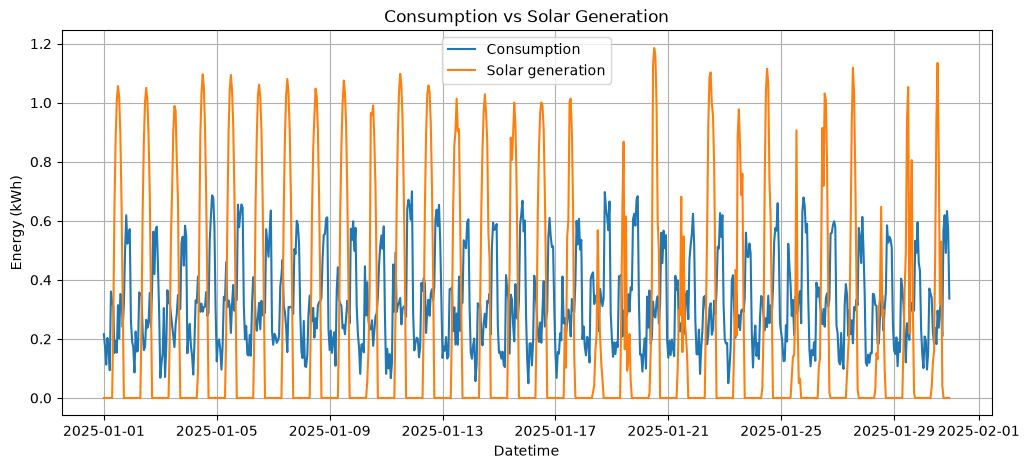

In [19]:
plt.figure(figsize=(12, 5))

plt.plot(
    df["datetime"],
    df["consumption_kwh"],
    label="Consumption"
)

plt.plot(
    df["datetime"],
    df["solar_generation_kwh"],
    label="Solar generation"
)

plt.title("Consumption vs Solar Generation")
plt.xlabel("Datetime")
plt.ylabel("Energy (kWh)")
plt.grid(True)
plt.legend()

plt.show()

## Self-consumption without battery

First, we simulate the photovoltaic system without battery storage.

In this case, solar energy can only be used directly at the same hour when it is produced.

In [20]:
self_consumed_no_battery, grid_import_no_battery, solar_surplus_no_battery = simulate_self_consumption(
    consumption_kwh,
    solar_generation_kwh
)

df["self_consumed_no_battery_kwh"] = self_consumed_no_battery
df["grid_import_no_battery_kwh"] = grid_import_no_battery
df["solar_surplus_no_battery_kwh"] = solar_surplus_no_battery

df[
    [
        "datetime",
        "consumption_kwh",
        "solar_generation_kwh",
        "self_consumed_no_battery_kwh",
        "grid_import_no_battery_kwh",
        "solar_surplus_no_battery_kwh"
    ]
].head(24)

,datetime,consumption_kwh,solar_generation_kwh,self_consumed_no_battery_kwh,grid_import_no_battery_kwh,solar_surplus_no_battery_kwh
0,2025-01-01 00:00:00,0.216180,0.000000,0.000000,0.216180,0.000000
1,2025-01-01 01:00:00,0.172143,0.000000,0.000000,0.172143,0.000000
2,2025-01-01 02:00:00,0.113076,0.000000,0.000000,0.113076,0.000000
3,2025-01-01 03:00:00,0.203159,0.000000,0.000000,0.203159,0.000000
4,2025-01-01 04:00:00,0.170268,0.000000,0.000000,0.170268,0.000000
5,2025-01-01 05:00:00,0.094099,0.000000,0.000000,0.094099,0.000000
6,2025-01-01 06:00:00,0.360398,0.000000,0.000000,0.360398,0.000000
7,2025-01-01 07:00:00,0.323098,0.000000,0.000000,0.323098,0.000000
8,2025-01-01 08:00:00,0.310870,0.261225,0.261225,0.049645,0.000000
9,2025-01-01 09:00:00,0.152328,0.650010,0.152328,0.000000,0.497682


## Battery simulation

We now simulate a battery that stores solar surplus and later discharges to cover household consumption.

In [21]:
battery_results = simulate_battery(
    consumption_kwh,
    solar_generation_kwh,
    battery_capacity_kwh,
    battery_efficiency=battery_efficiency,
    max_charge_power_kw=max_charge_power_kw,
    max_discharge_power_kw=max_discharge_power_kw,
    initial_battery_state_kwh=initial_battery_state_kwh
)

df["self_consumed_with_battery_kwh"] = battery_results["self_consumed_kwh"]
df["battery_charge_kwh"] = battery_results["battery_charge_kwh"]
df["battery_discharge_kwh"] = battery_results["battery_discharge_kwh"]
df["grid_import_with_battery_kwh"] = battery_results["grid_import_kwh"]
df["solar_surplus_with_battery_kwh"] = battery_results["solar_surplus_kwh"]
df["battery_state_kwh"] = battery_results["battery_state_kwh"]

df[
    [
        "datetime",
        "consumption_kwh",
        "solar_generation_kwh",
        "battery_charge_kwh",
        "battery_discharge_kwh",
        "grid_import_with_battery_kwh",
        "solar_surplus_with_battery_kwh",
        "battery_state_kwh"
    ]
].head(24)

,datetime,consumption_kwh,solar_generation_kwh,battery_charge_kwh,battery_discharge_kwh,grid_import_with_battery_kwh,solar_surplus_with_battery_kwh,battery_state_kwh
0,2025-01-01 00:00:00,0.216180,0.000000,0.000000,0.000000,0.216180,0.0,0.000000
1,2025-01-01 01:00:00,0.172143,0.000000,0.000000,0.000000,0.172143,0.0,0.000000
2,2025-01-01 02:00:00,0.113076,0.000000,0.000000,0.000000,0.113076,0.0,0.000000
3,2025-01-01 03:00:00,0.203159,0.000000,0.000000,0.000000,0.203159,0.0,0.000000
4,2025-01-01 04:00:00,0.170268,0.000000,0.000000,0.000000,0.170268,0.0,0.000000
5,2025-01-01 05:00:00,0.094099,0.000000,0.000000,0.000000,0.094099,0.0,0.000000
6,2025-01-01 06:00:00,0.360398,0.000000,0.000000,0.000000,0.360398,0.0,0.000000
7,2025-01-01 07:00:00,0.323098,0.000000,0.000000,0.000000,0.323098,0.0,0.000000
8,2025-01-01 08:00:00,0.310870,0.261225,0.000000,0.000000,0.049645,0.0,0.000000
9,2025-01-01 09:00:00,0.152328,0.650010,0.497682,0.000000,0.000000,0.0,0.447914


## Energy summary

We compare the main energy indicators with and without battery storage.

In [22]:
total_consumption = df["consumption_kwh"].sum()
total_solar_generation = df["solar_generation_kwh"].sum()

total_grid_import_no_battery = df["grid_import_no_battery_kwh"].sum()
total_grid_import_with_battery = df["grid_import_with_battery_kwh"].sum()

total_solar_surplus_no_battery = df["solar_surplus_no_battery_kwh"].sum()
total_solar_surplus_with_battery = df["solar_surplus_with_battery_kwh"].sum()

self_sufficiency_no_battery = 1 - (
    total_grid_import_no_battery / total_consumption
)

self_sufficiency_with_battery = 1 - (
    total_grid_import_with_battery / total_consumption
)

self_consumption_no_battery = (
    df["self_consumed_no_battery_kwh"].sum() / total_solar_generation
)

self_consumption_with_battery = (
    (
        df["self_consumed_with_battery_kwh"].sum()
        + df["battery_charge_kwh"].sum()
    )
    / total_solar_generation
)

summary = pd.DataFrame({
    "metric": [
        "Total consumption (kWh)",
        "Total solar generation (kWh)",
        "Grid import without battery (kWh)",
        "Grid import with battery (kWh)",
        "Solar surplus without battery (kWh)",
        "Solar surplus with battery (kWh)",
        "Self-sufficiency without battery",
        "Self-sufficiency with battery",
        "Self-consumption without battery",
        "Self-consumption with battery"
    ],
    "value": [
        total_consumption,
        total_solar_generation,
        total_grid_import_no_battery,
        total_grid_import_with_battery,
        total_solar_surplus_no_battery,
        total_solar_surplus_with_battery,
        self_sufficiency_no_battery,
        self_sufficiency_with_battery,
        self_consumption_no_battery,
        self_consumption_with_battery
    ]
})

summary

,metric,value
0,Total consumption (kWh),230.483656
1,Total solar generation (kWh),167.594865
2,Grid import without battery (kWh),163.792646
3,Grid import with battery (kWh),72.979176
4,Solar surplus without battery (kWh),100.903855
5,Solar surplus with battery (kWh),0.000000
6,Self-sufficiency without battery,0.289352
7,Self-sufficiency with battery,0.683365
8,Self-consumption without battery,0.397930
9,Self-consumption with battery,1.000000


## Grid import comparison

Battery storage reduces the amount of electricity imported from the grid by shifting solar surplus to later hours.

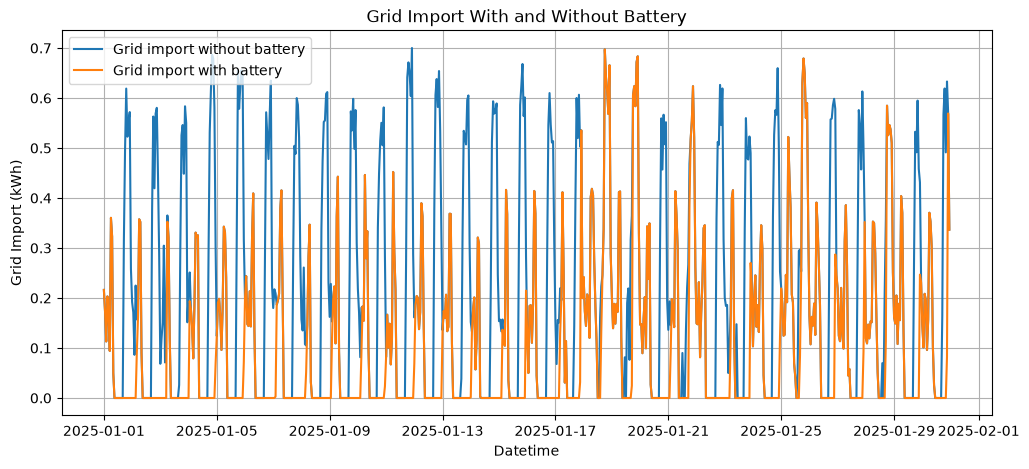

In [23]:
plt.figure(figsize=(12, 5))

plt.plot(
    df["datetime"],
    df["grid_import_no_battery_kwh"],
    label="Grid import without battery"
)

plt.plot(
    df["datetime"],
    df["grid_import_with_battery_kwh"],
    label="Grid import with battery"
)

plt.title("Grid Import With and Without Battery")
plt.xlabel("Datetime")
plt.ylabel("Grid Import (kWh)")
plt.grid(True)
plt.legend()

plt.show()

## Solar surplus comparison

Battery storage also reduces solar surplus by storing part of the excess generation.

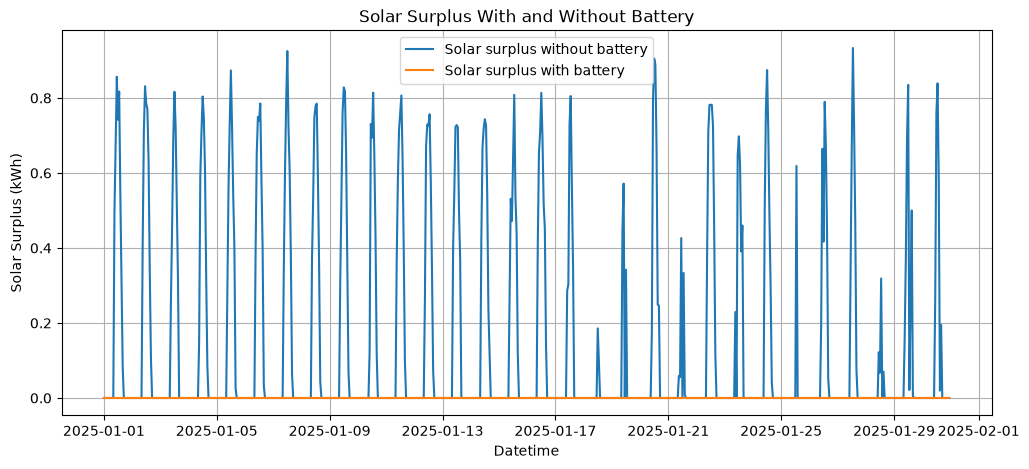

In [24]:
plt.figure(figsize=(12, 5))

plt.plot(
    df["datetime"],
    df["solar_surplus_no_battery_kwh"],
    label="Solar surplus without battery"
)

plt.plot(
    df["datetime"],
    df["solar_surplus_with_battery_kwh"],
    label="Solar surplus with battery"
)

plt.title("Solar Surplus With and Without Battery")
plt.xlabel("Datetime")
plt.ylabel("Solar Surplus (kWh)")
plt.grid(True)
plt.legend()

plt.show()

## Battery state of charge

The battery state of charge shows how the battery charges during solar production hours and discharges when consumption exceeds solar generation.

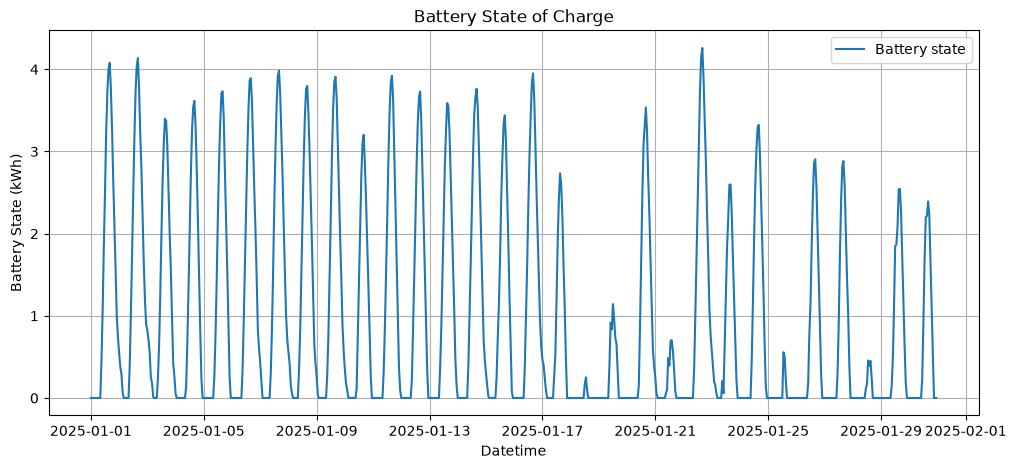

In [25]:
plt.figure(figsize=(12, 5))

plt.plot(
    df["datetime"],
    df["battery_state_kwh"],
    label="Battery state"
)

plt.title("Battery State of Charge")
plt.xlabel("Datetime")
plt.ylabel("Battery State (kWh)")
plt.grid(True)
plt.legend()

plt.show()

## Cumulative energy flows

Cumulative energy flows help compare total consumption, solar production, grid imports and solar surplus over the simulated period.

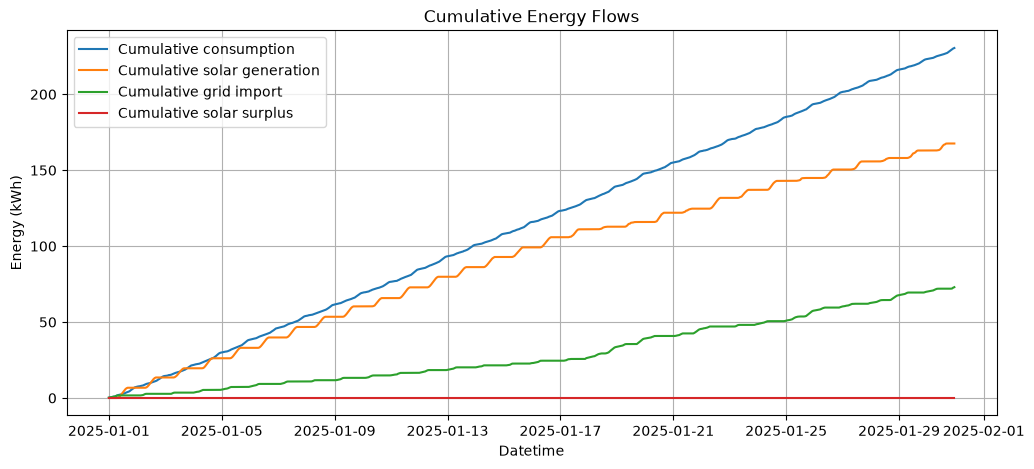

In [26]:
plt.figure(figsize=(12, 5))

plt.plot(
    df["datetime"],
    df["consumption_kwh"].cumsum(),
    label="Cumulative consumption"
)

plt.plot(
    df["datetime"],
    df["solar_generation_kwh"].cumsum(),
    label="Cumulative solar generation"
)

plt.plot(
    df["datetime"],
    df["grid_import_with_battery_kwh"].cumsum(),
    label="Cumulative grid import"
)

plt.plot(
    df["datetime"],
    df["solar_surplus_with_battery_kwh"].cumsum(),
    label="Cumulative solar surplus"
)

plt.title("Cumulative Energy Flows")
plt.xlabel("Datetime")
plt.ylabel("Energy (kWh)")
plt.grid(True)
plt.legend()

plt.show()

## Conclusions

The simulation shows that battery storage can significantly reduce grid imports and increase self-sufficiency.

Without battery storage, solar energy must be consumed at the same time it is produced. This creates solar surplus during high production hours and grid imports during low production hours.

With battery storage, part of the solar surplus is shifted to later hours, reducing grid dependency and improving the overall use of photovoltaic generation.

This confirms the usefulness of the battery simulation module before moving to the economic optimization stage.

Using PVGIS data makes the simulation more realistic than using a repeated synthetic daily solar curve, because the solar generation profile depends on the selected location and historical hourly solar conditions.